# SABRE with PulsPol

## Imports

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib import ticker, cm 
from matplotlib.colors import Normalize, CenteredNorm
import spindata
from functools import reduce

import spinSimulations.spin as s
from spinSimulations.solver_H import amplitude
from spinSimulations.solver_L import *
from spinSimulations.plotter import *
from scipy.linalg import expm, null_space
from scipy.integrate import solve_ivp

## Spin System setters

In [2]:
# THESE ARE GLOBAL VARS
ss_S = op_S = ppms_S = Js_S = None
ss_C = op_C = ppms_C = Js_C = None
nuc = None

# THIS IS A SETTER FOR THEM
def set_up_spin_system(nuclei='15N'):
    ###################################################
    ### Set up spin system of the free substrate ###
    global ss_S, op_S
    global ppms_S, Js_S
    
    Js_S = np.array(
        [[0]]
    )

    ppms_S = np.array([300])*1e-6

    n_spins = 1

    nuclei_list = [nuclei]

    ss_S = s.System(
        n_spins, nuclei_list=nuclei_list.copy(),
        is_sparse=False,
        Js=Js_S.copy(),
        ppms=ppms_S.copy(),
    )
    
    op_S = ss_S.op

    ###################################################
    ### Set up spin system of the SABRE complex
    global ss_C, op_C
    global ppms_C, Js_C
    global nuc
    #global idx_H, idx_D, idx_X
    
    Js_C = np.array(
            [[0, -7.7, -21],
            [0, 0, 0],
            [0, 0, 0]]
        )

    ppms_C = np.array([-22,-22, 0])*1e-6

    n_spins = 3

    nuclei_list = 2 * ["1H"] + [nuclei]

    ss_C = s.System(
        n_spins, nuclei_list=nuclei_list.copy(),
        is_sparse=False,
        Js=Js_C.copy(),
        ppms=ppms_C.copy(),
    )

    op_C = ss_C.op
    nuc = nuclei
T1_S = np.array([20])
T1_C = np.array([6, 6, 20])

set_up_spin_system()

## Helper function

In [3]:
def arg_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

## PP conditions

In [209]:
def pulse_pol_params(J, phi=np.pi/2, n=0, sign='+'):
    if sign == '+':
        tau = (2 * n + 1 + phi / np.pi) / J
    elif sign =='-':
        tau = (2 * n + 1 - phi / np.pi) / J
    else:
        raise ValueError('Sign can only be + or -')
    if tau < 0:
        raise ValueError(f'You got the negative time {tau:.2f}')
    return tau

In [5]:
tau_pp = pulse_pol_params(7.7)
print(f'{tau_pp:.2f}')

0.19


In [6]:
ss_C.nuclei_list

['1H', '1H', '15N']

## Calculations

In [7]:
#Density matrix of pure pH2
rho_pH2=np.array([
    [0,0,0,0],
    [0,0.5,-0.5,0],
    [0,-0.5,0.5,0],
    [0,0,0,0]
]) 

#Initialization of the composite system matrix
def SABRE_SO(
    ss_S, ss_C, B0, kd, W, omega_n=0, 
    phase=0, ZULF=True, on_res=None):
    #Generate partial trace superoperator
    Tr = part_trace_SO(ss_S, ss_C)
  
    #Generate Kronecker product superoperator
    Kron = kron_SO(ss_S, ss_C, rho_pH2)

    #Calculate relaxation superoperator of the substrate
    R_S = relax_phenom_SO(ss_S, T1_S)
    
    # Calculate Hamiltonian of the substrate
    if on_res is None: 
        ham_S = ss_S.build_ham_lab(field=B0, ZULF=ZULF)
    else:
        ham_S = ss_S.build_ham_rf(field=B0, nucs_on_res=on_res)
        
    
    # Add B1 into the substrate
    # B1 should be provide in rad*s-1
    ham_S_B1 = omega_n * ss_S.op(0, phi=phase)
    
    # === #
    #Generate the Liouvillian of the substrate
    L_S = -1j*comm_SO(ham_S + ham_S_B1) + R_S

    #Calculate relaxation superoperator of the complex
    R_C = relax_phenom_SO(ss_C, T1_C)

    #Calculate Hamiltonian superoperator of the complex
    if on_res is None: 
        ham_C = ss_C.build_ham_lab(field=B0, ZULF=ZULF)
    else:
        ham_C = ss_C.build_ham_rf(field=B0, nucs_on_res=on_res)
    ham_C_B1= omega_n * ss_C.op(2, phi=phase)
    
    #Generate Liouvillian of the complex
    L_C = -1j*comm_SO(ham_C + ham_C_B1) + R_C

    #Generate SABRE matrix for the composite system
    M = np.block([
        [L_S - kd*W*np.eye(ss_S.get_spin_dim()**2), kd*Tr],
        [kd*W*Kron, L_C-kd*np.eye(ss_C.get_spin_dim()**2)]
    ])

    return M

# Rotation 
def SABRE_SO_rot(ss_S, ss_C, angle=np.pi/2, phase=0):
    # Add B1 into the substrate
    # B1 should be provide in rad*s-1
    ham_S_B1 = angle * ss_S.op(0, phi=phase)
    
    # === #
    #Generate the Liouvillian of the substrate
    L_S = -1j*comm_SO(ham_S_B1)

    ham_C_B1 = angle * ss_C.op(2, phi=phase)
    
    #Generate Liouvillian of the complex
    L_C = -1j * comm_SO(ham_C_B1)

    #Generate SABRE matrix for the composite system
    M = sp.linalg.block_diag(L_S, L_C)

    return M

In [8]:
# Set magnetic field for polariztion transfer in T
# B0 = 0.3*1e-6
B0_PP = 5e-3
B0_SNEATH = 0.3e-6
kd = 40
W = 0.1

rho_S=np.eye(ss_S.get_spin_dim(), dtype = np.complex128) #Non polarized density matrix for substrate
rho_S=rho_S/np.trace(rho_S)
rho_C=np.eye(ss_C.get_spin_dim(), dtype = np.complex128)  #Non polarized density matrix for complex
rho_C=rho_C/np.trace(rho_C)
#Density matrices -> concentration normalized density matrices
S_conc=1
C_conc=1*W
sigma_S = S_conc*rho_S 
sigma_C = C_conc*rho_C 
sigma_S = mat2vec(sigma_S)
sigma_C = mat2vec(sigma_C)
#Density matrix of the composite system
sigma_0 = np.hstack([sigma_S, sigma_C])

# Generate the observables (z-polarization)
obs_S = ss_S.pol_level(0)
obs_S = mat2vec(obs_S)
obs_C = ss_C.pol_level(2)
obs_C = mat2vec(obs_C)

In [30]:
class PP_SABRE:
    def __init__(
        self, tau_pp, ss_S, ss_C, kd, W, 
        b0=1e-3, ph_shift=np.pi/2, b1_pulse=None, nuc='13C'):
        
        self.tau_pp = tau_pp
        self.ph_shift = ph_shift
        self.b0 = b0
        self.b1_pulse = b1_pulse
        self.ZULF = True if b0 < 5e-6 else False
        self.nuc=nuc
        # Spin System params
        self.ss_S = ss_S
        self.ss_C = ss_C
        self.kd = kd
        self.W = W
        
        if self.b1_pulse is None:
            self._update_unis_pulse()
        else:
            self.omega_n = self.b1_pulse * abs(spindata.gamma(nuc))
            self.tau_180 = np.pi / self.omega_n
            self.tau_90 = self.tau_180 / 2
            self._update_unis_pulse()
        self.update_uni_free()
    
    def _update_unis_pulse(self):
        ph_x = 0
        ph_y = np.pi / 2
        ph_x_shift = ph_x + self.ph_shift
        ph_y_shift = ph_y + self.ph_shift
        
        unis_pp = {
            '90' : {
                'y': {},
                'y_shift': {}
            },        
            '180' : {
                'x': {},
                'x_shift': {}
            }
        }
        if self.b1_pulse is not None:
            # print('Update real pulses')
            unis_pp['90']['y'] = expm(
                SABRE_SO(
                    self.ss_S, self.ss_C, self.b0, 
                    self.kd, self.W, omega_n=self.omega_n, 
                    phase=ph_y, ZULF=self.ZULF, on_res=[self.nuc]
                ) * self.tau_90
            )
            unis_pp['90']['y_shift'] = expm(
                SABRE_SO(
                    self.ss_S, self.ss_C, self.b0, 
                    self.kd, self.W, omega_n=self.omega_n, 
                    phase=ph_y_shift, ZULF=self.ZULF, on_res=[self.nuc]
                ) * self.tau_90
            )
            
            # 180 X and Y

            unis_pp['180']['x'] = expm(
                SABRE_SO(
                    self.ss_S, self.ss_C, self.b0, 
                    self.kd, self.W, omega_n=self.omega_n, 
                    phase=ph_x, ZULF=self.ZULF, on_res=[self.nuc]
                ) * self.tau_180
            )
            
            unis_pp['180']['x_shift'] = expm(
                SABRE_SO(
                    self.ss_S, self.ss_C, self.b0, 
                    self.kd, self.W, omega_n=self.omega_n, 
                    phase=ph_x_shift, ZULF=self.ZULF, on_res=[self.nuc]
                ) * self.tau_180
            )
            
        else:
            unis_pp['90']['y'] = expm(
                SABRE_SO_rot(
                    self.ss_S, self.ss_C, 
                    angle=np.pi/2, phase=ph_y
                )
            )
            unis_pp['90']['y_shift'] = expm(
                SABRE_SO_rot(
                    self.ss_S, self.ss_C, 
                    angle=np.pi/2, phase=ph_y_shift
                )
            )
            
            # 180 X and Y

            unis_pp['180']['x'] = expm(
                SABRE_SO_rot(
                    self.ss_S, self.ss_C, 
                    angle=np.pi, phase=ph_x
                )
            )
            
            unis_pp['180']['x_shift'] = expm(
                SABRE_SO_rot(
                    self.ss_S, self.ss_C,
                    angle=np.pi, phase=ph_x_shift
                )
            )
        self.unis_pp = unis_pp
    
    def update_uni_free(self):
        tau_free = self.tau_pp / 4
        
        if self.b1_pulse is not None:
            tau_free -= self.tau_180
            
        if tau_free < 0:
            raise Exception(
                "The pulse length is too long"
            )
        
        self.uni_free = expm(
            SABRE_SO(
                self.ss_S, self.ss_C, self.b0, 
                self.kd, self.W, on_res=[self.nuc]
            ) * tau_free
        )
        
    def update(self, **kwargs):
        for key, value in kwargs.items():
            if value is not None:
                setattr(self, key, value)
                
        self.update_uni_free()
        if self.b1_pulse is not None or ('ph_shift' in kwargs):
            # print('Updating pulses')
            self._update_unis_pulse()
        
    def calc(self):
        unis_pp = self.unis_pp
        uni_free = self.uni_free 
        
        unis = [
            unis_pp['90']['y'],
            uni_free,
            unis_pp['180']['x'],
            uni_free,
            unis_pp['90']['y'],
            # === half of the sequence === #
            unis_pp['90']['y_shift'],
            uni_free,
            unis_pp['180']['x_shift'],
            uni_free,
            unis_pp['90']['y_shift']
        ]
        
        return reduce(
            # x is accumulated vale, y is new value
            lambda x, y: y @ x, unis, 
            np.eye(uni_free.shape[0])
        )

In [31]:
tau_pp = pulse_pol_params(7.7)

In [124]:
B0_PP = 1e-3
B0_SNEATH = 0.3e-6
kd = 25
W = 0.1


pp_sabre = PP_SABRE(
    26e-3, ss_S, ss_C, kd, W, 
    nuc='15N', b0=B0_PP, ph_shift=0.84,
    # b1_pulse=1e-3
)

uni_pp = pp_sabre.calc()

uni_sneath = expm(
    SABRE_SO(ss_S, ss_C, B0_SNEATH, kd, W) * tau_pp
)


In [127]:
time_overall = 200
n_cycle = int(time_overall / tau_pp)

sigma_0_pp = np.hstack([sigma_S, sigma_C])
sigma_0_sneath = np.hstack([sigma_S, sigma_C])
idx_S = ss_S.get_spin_dim()**2
idx_fin = idx_S + ss_C.get_spin_dim()**2
P_S = {
    'PP': {
        'free'  : np.empty(n_cycle),
        'bound' : np.empty(n_cycle),
    },
    'SNEATH': {
        'free'  : np.empty(n_cycle),
        'bound' : np.empty(n_cycle)
    }
}

for i in range(n_cycle):
    sigma_0_pp = uni_pp @ sigma_0_pp
    P_S['PP']['free'][i] = amplitude_v(obs_S, sigma_0_pp[:idx_S])
    P_S['PP']['bound'][i] = amplitude_v(obs_C, sigma_0_pp[idx_S:idx_fin])
    sigma_0_sneath = uni_sneath @ sigma_0_sneath
    P_S['SNEATH']['free'][i] = amplitude_v(obs_S, sigma_0_sneath[:idx_S])
    P_S['SNEATH']['bound'][i] = amplitude_v(obs_C, sigma_0_sneath[idx_S:idx_fin])


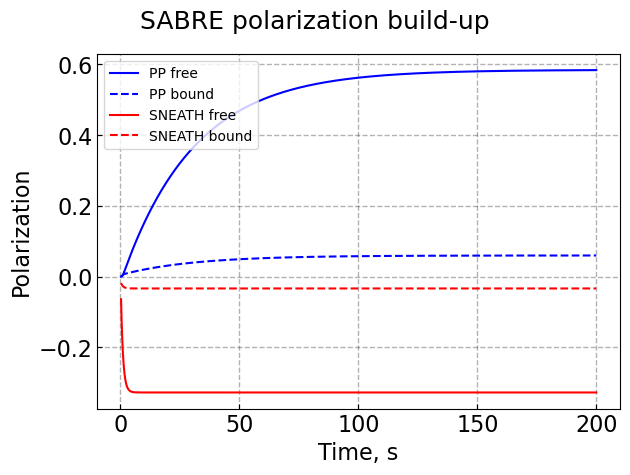

In [128]:
fig, (ax1) = plt.subplots(nrows=1)

timescale = tau_pp * (np.arange(n_cycle) + 1) 
ax1.plot(timescale, P_S['PP']['free'], 'b', label='PP free')
ax1.plot(timescale, P_S['PP']['bound'], 'b--', label='PP bound')
ax1.plot(timescale, P_S['SNEATH']['free'], 'r', label='SNEATH free')
ax1.plot(timescale, P_S['SNEATH']['bound'], 'r--', label='SNEATH bound')
ax1.legend()

ax1.set_xlabel('Time, s',fontsize=16)

ax1.set_ylabel('Polarization',fontsize=16)

ax1.tick_params( axis='both', which='major', labelsize=16,direction='in')

ax1.grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
ax1.grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

fig.suptitle(f"SABRE polarization build-up" ,fontsize=18)
plt.tight_layout()

Optimizing 

## K0 vs Phase

Let's estimate k0 vs phase.

### Ideal Pulses

In [37]:
tau_pp_0 = pulse_pol_params(7.7, phi=0)

In [138]:
kds = np.geomspace(1, 300, 40)
phs = np.linspace(-7 * np.pi / 8, 7 * np.pi / 8, 50)
# phs = np.linspace(-3 * np.pi / 4, -np.pi / 2, 90)
tau_pps = np.array(
    [pulse_pol_params(7.7, phi=ph) for ph in phs]
)

P_2 = {
    'free': np.zeros([len(tau_pps),len(kds)]),
    'bound': np.zeros([len(tau_pps),len(kds)])
}
sigma_0_pp = np.hstack([sigma_S, sigma_C])

tau_ppsv, kdsv = np.meshgrid(tau_pps*1e+3, kds, indexing="ij")

In [139]:
time_overall = 50

for i_tau, (tau_pp, ph) in enumerate(zip(tau_pps, phs)):
    pp_sabre = PP_SABRE(
        tau_pp, ss_S, ss_C, 40, W, 
        nuc='15N', b0=B0_PP, ph_shift=ph# , b1_pulse=1e+3
    )
    for i_k, kd in enumerate(kds):
    
        #Set the magnetic field 
        pp_sabre.update(kd=kd)
        uni_pp = pp_sabre.calc()
        #Normalize the steady-state density operator
        n_cycles = int(time_overall / tau_pp)
        uni_fin = np.linalg.matrix_power(uni_pp, n_cycles)

        #Calculate the polarization level
        sigma_fin = uni_fin @ sigma_0_pp
        P_2['free'][i_tau, i_k] = amplitude_v(obs_S, sigma_fin[:idx_S])
        P_2['bound'][i_tau, i_k] = amplitude_v(obs_C, sigma_fin[idx_S:idx_fin])

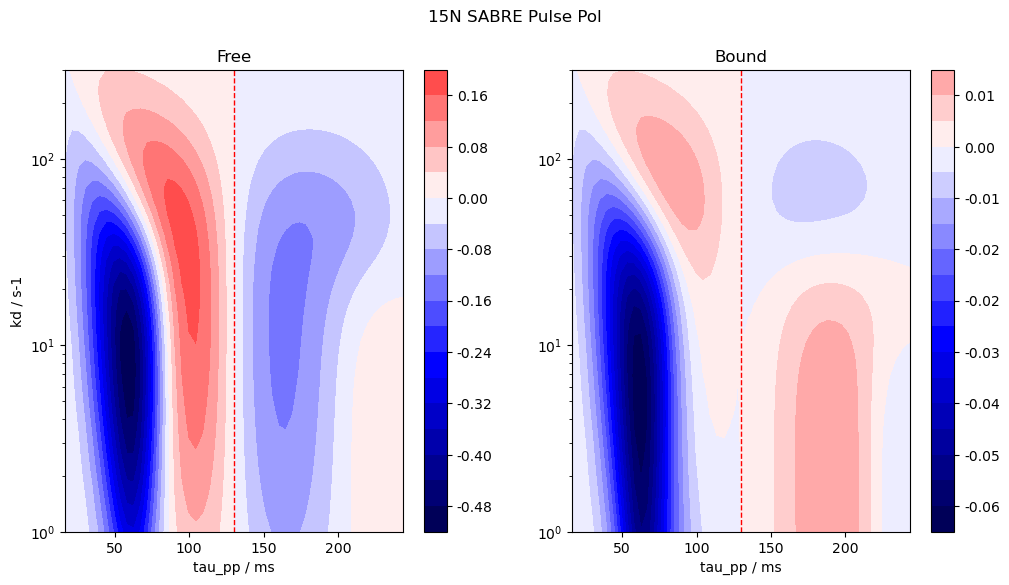

In [140]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE Pulse Pol')
my_cmap = 'seismic'


ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    tau_ppsv, kdsv, P_2['free'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel('tau_pp / ms')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
ax1.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    tau_ppsv, kdsv, P_2['bound'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel('tau_pp / ms')
ax2.set_yscale('log')
ax2.set_title('Bound')
ax2.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

In [19]:
tau_pps[np.abs(P_2['free'][:, arg_nearest(kds, 40)]).argmax()] 

0.04778928936232308

In [20]:
phs[np.abs(P_2['free'][:, arg_nearest(kds, 40)]).argmax()] 

-1.9855571546564703

### Real 1 mT pulses

In [32]:
time_overall = 30
P_2_real = {
    'free'  : np.zeros([len(tau_pps),len(kds)]),
    'bound' : np.zeros([len(tau_pps),len(kds)])
}
for i_tau, (tau_pp, ph) in enumerate(zip(tau_pps, phs)):
    pp_sabre = PP_SABRE(
        tau_pp, ss_S, ss_C, kd, W, 
        nuc='15N', b0=B0_PP, ph_shift=ph, b1_pulse=1e-3
    )
    for i_k, kd in enumerate(kds):
        pp_sabre.update(kd=kd)
        uni_pp = pp_sabre.calc()
        #Normalize the steady-state density operator
        n_cycles = int(time_overall / tau_pp)
        uni_fin = np.linalg.matrix_power(uni_pp, n_cycles)

        #Calculate the polarization level
        sigma_fin = uni_fin @ sigma_0_pp
        P_2_real['free'][i_tau, i_k] = amplitude_v(obs_S, sigma_fin[:idx_S])
        P_2_real['bound'][i_tau, i_k] = amplitude_v(obs_C, sigma_fin[idx_S:idx_fin])

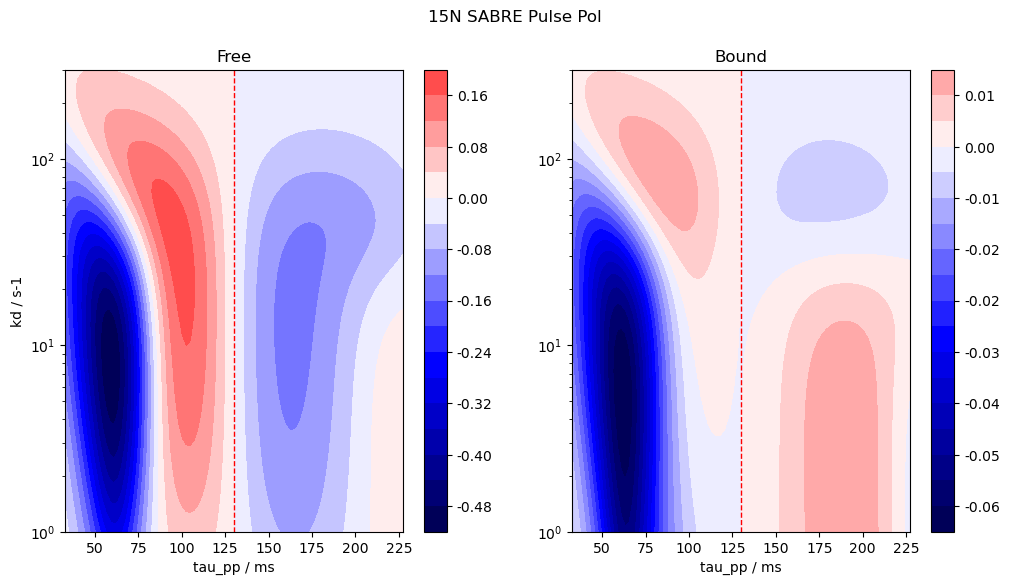

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE Pulse Pol')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    tau_ppsv, kdsv, P_2_real['free'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel('tau_pp / ms')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
ax1.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    tau_ppsv, kdsv, P_2_real['bound'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel('tau_pp / ms')
ax2.set_yscale('log')
ax2.set_title('Bound')
ax2.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

Cool, there is no difference.

### SABRE-SHEATH

In [136]:
B0s = np.linspace(0, 3e-6, 50)

P_2_SHEATH = {
    'free'  : np.zeros([len(tau_pps),len(kds)]),
    'bound' : np.zeros([len(tau_pps),len(kds)])
}
sigma_0_SHEATH = np.hstack([sigma_S, sigma_C])

B0sv, kdsv = np.meshgrid(B0s*1e+6, kds, indexing="ij")

In [137]:
time_overall = 30
for i_B0, B0 in enumerate(B0s):
    for i_k, kd in enumerate(kds):
        uni_sheath = expm(
            SABRE_SO(ss_S, ss_C, B0, kd, W) * time_overall
        )
        sigma_fin = uni_sheath @ sigma_0_pp
        P_2_SHEATH['free'][i_B0, i_k] = amplitude_v(
                                                obs_S, sigma_fin[:idx_S])
        P_2_SHEATH['bound'][i_B0, i_k] = amplitude_v(
                                                obs_C, sigma_fin[idx_S:idx_fin])

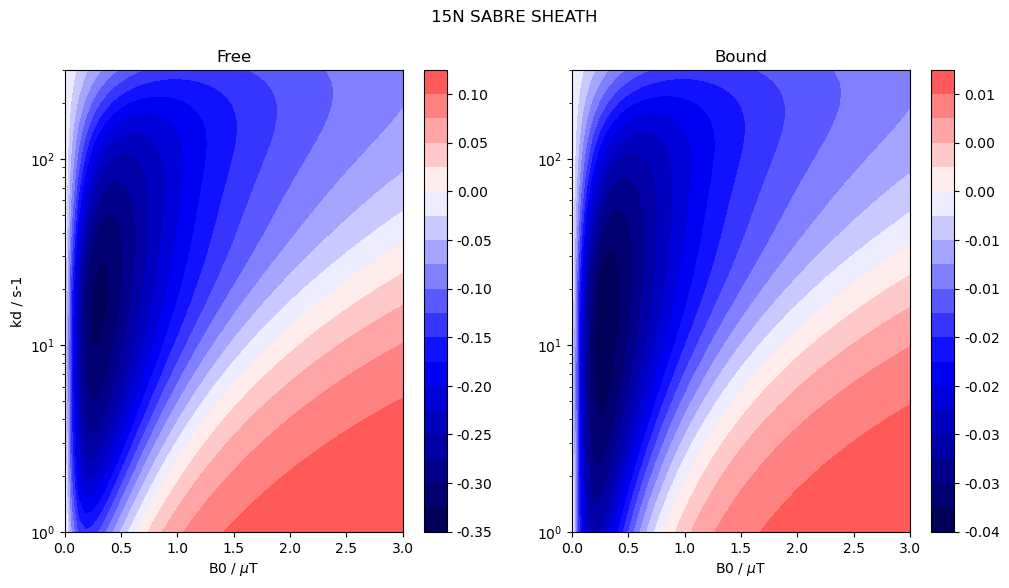

In [143]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE SHEATH')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    B0sv, kdsv, P_2_SHEATH['free'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel(r'B0 / $\mu$T')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    B0sv, kdsv, P_2_SHEATH['bound'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel(r'B0 / $\mu$T')
ax2.set_yscale('log')
ax2.set_title('Bound')
# ax2.axvline(B0s, color='red', lw=1, linestyle='--')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

### All parameter space, ideal Pulses

In [105]:
kds = np.geomspace(1, 300, 40)
phs = np.linspace(-7 * np.pi / 8, 7 * np.pi / 8, 50)
tau_pps = np.array(
    [pulse_pol_params(7.7, phi=ph) for ph in phs]
)

P_2_long = {
    'free' : np.zeros([len(tau_pps), len(phs), len(kds)]),
    'bound' : np.zeros([len(tau_pps), len(phs), len(kds)]),
}
sigma_0_pp = np.hstack([sigma_S, sigma_C])

tau_ppsv, kdsv = np.meshgrid(tau_pps*1e+3, kds, indexing="ij")

In [106]:
time_overall = 50

for i_ph, ph in enumerate(phs):
    pp_sabre = PP_SABRE(
        tau_pp, ss_S, ss_C, 40, W, 
        nuc='15N', b0=B0_PP, ph_shift=ph# , b1_pulse=1e+3
    )
    for i_tau, tau_pp in enumerate(tau_pps):
        for i_k, kd in enumerate(kds):
            #Set the magnetic field 
            pp_sabre.update(kd=kd, tau_pp=tau_pp)
            uni_pp = pp_sabre.calc()
            #Normalize the steady-state density operator
            n_cycles = int(time_overall / tau_pp)
            uni_fin = np.linalg.matrix_power(uni_pp, n_cycles)

            #Calculate the polarization level
            sigma_fin = uni_fin @ sigma_0_pp
            P_2_long['free'][i_tau, i_ph, i_k] = amplitude_v(
                obs_S, sigma_fin[:idx_S]
            )
            P_2_long['bound'][i_tau, i_ph, i_k] = amplitude_v(
                obs_C, sigma_fin[idx_S:idx_fin]
            )

Let's pickle it to avoid recalculation.

In [107]:
np.save('SABRE_PP_res/pol_all_depenecies.npy', P_2_long)

In [63]:
# To load
# P_2_long = np.load('SABRE_PP_res/pol_all_depenecies.npy', allow_pickle=True)[()]

#### Finding the maximum values

In [108]:
# tau, phase, k_d
P_2_free = P_2_long['free']
P_2_argmax_phase = np.argmax(np.abs(P_2_free), axis=1)
P_2_argmax_tau = np.argmax(np.abs(P_2_free), axis=0)

Let's try to see what's going on for tau maximization.

In [109]:
P_2_max = {
    'tau': np.take_along_axis(
        P_2_free, P_2_argmax_phase[:, None, :], axis=1
    ).squeeze(),
    'phase' : np.take_along_axis(
        P_2_free, P_2_argmax_tau[None, :, :], axis=0
    ).squeeze()
}

Ok, let's try and plot.

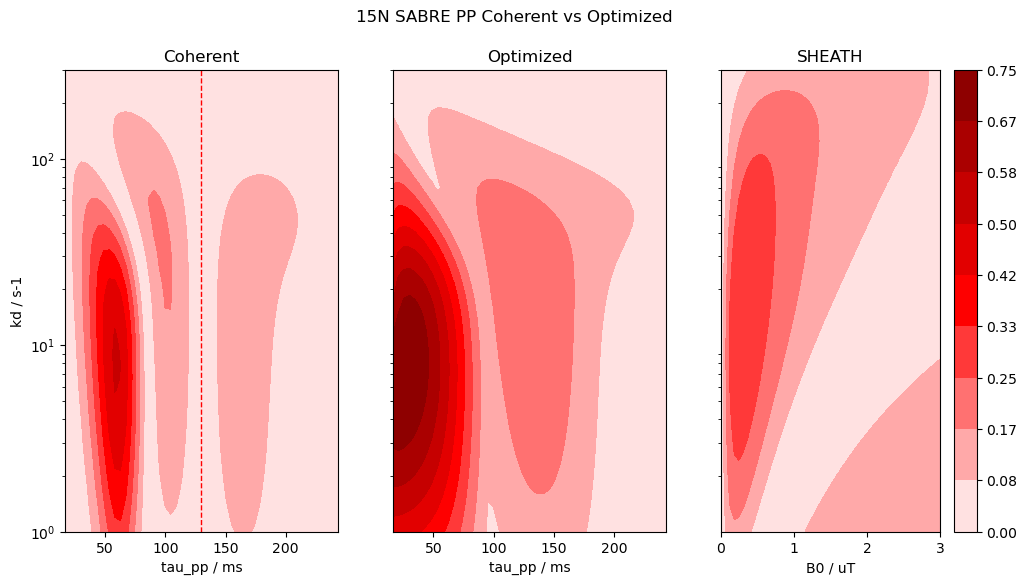

In [147]:
fig, axs = plt.subplots(
    1, 3, figsize=(12, 6)
)

fig.suptitle('15N SABRE PP Coherent vs Optimized')
my_cmap = 'seismic'


ax1 = axs[0]
ax2 = axs[1]
ax3 = axs[2]

levels = np.linspace(
    0, np.max(P_2_max['tau']), 10
)

cs1 = ax1.contourf(
    tau_ppsv, kdsv, np.abs(P_2['free']), levels=levels, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel('tau_pp / ms')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Coherent')
ax1.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
# fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    tau_ppsv, kdsv, np.abs(P_2_max['tau']), levels=levels, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel('tau_pp / ms')
ax2.set_yscale('log')
ax2.set_title('Optimized')
ax2.set_yticks([])


cs3 = ax3.contourf(
    B0sv, kdsv, np.abs(P_2_SHEATH['free']), levels=levels, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax3.set_xlabel('B0 / uT')
ax3.set_yscale('log')
ax3.set_title('SHEATH')
ax3.set_yticks([])

#
# normalizer = Normalize(levels[0], levels[-1])
fig.colorbar(cs2, ax=ax3, format='%.2f')

plt.show()

Let's find the base phase and tau for a given k_d

In [114]:
np.abs(P_2_free[:, :, arg_nearest(kds, 40)]).argmax()

132

In [115]:
max_kd = P_2_free[:, :, arg_nearest(kds, 40)]
ind_max = np.unravel_index(
    np.argmax(max_kd),  max_kd.shape
) 

In [116]:
print(
    f'The argmax time is {tau_pps[ind_max[0]]*1e+3:.0f} ms\n'
    f'The argmax phase is {phs[ind_max[1]]:.2f}'  
)


The argmax time is 26 ms
The argmax phase is 0.84


#### Optimal time and phase difference

Let's try and plot one phase-time plot.

In [190]:
kds

array([  1.        ,   1.15748649,   1.33977497,   1.55077142,
         1.79499696,   2.07768473,   2.404892  ,   2.78362999,
         3.2220141 ,   3.72943778,   4.31677384,   4.99660739,
         5.78350553,   6.6943295 ,   7.74859594,   8.96889509,
        10.38137487,  12.01630113,  13.90870618,  16.09913946,
        18.63453638,  21.56922405,  24.96608538,  28.89790646,
        33.44893623,  38.7166917 ,  44.81404747,  51.87165437,
        60.040739  ,  69.49634407,  80.44107916,  93.10946213,
       107.77294424, 124.74572663, 144.39149289, 167.13120187,
       193.45210774, 223.9182006 , 259.18229141, 300.        ])

In [199]:
kd_locs = np.geomspace(1, 300, 4)
tau_ppsv, phsv = np.meshgrid(tau_pps*1e+3, phs * 180 / np.pi, indexing="ij")

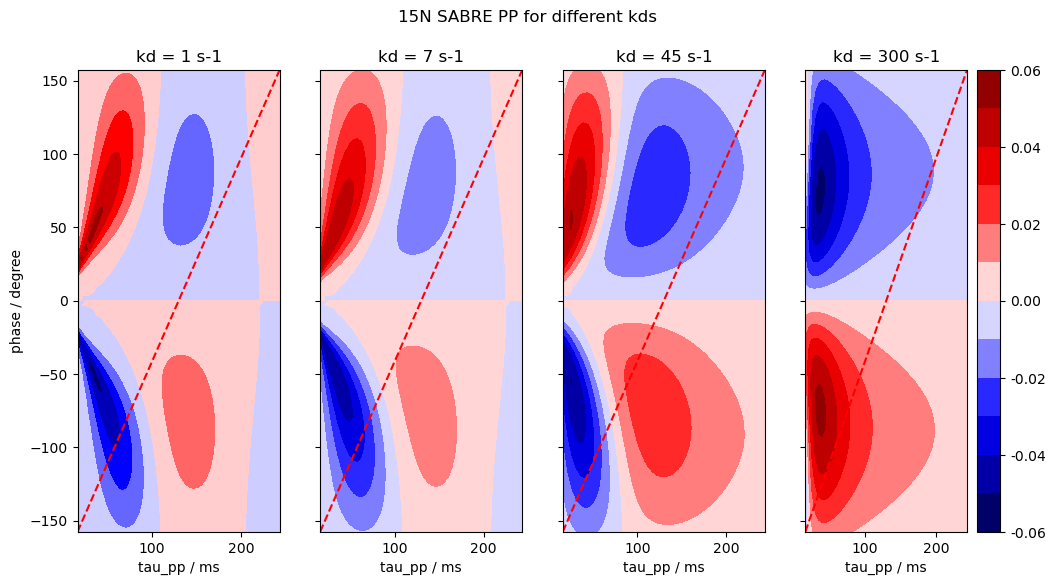

In [208]:
fig, axs = plt.subplots(1, len(kd_locs), figsize=(12, 6), sharey=True)

fig.suptitle(f'15N SABRE PP for different kds')
my_cmap = 'seismic'
n_levels = 10

for idx, (kd_loc, ax) in enumerate(zip(kd_locs, axs)):
    idx_kd = arg_nearest(kds, kd_loc)
    cs = ax.contourf(
        tau_ppsv, phsv, P_2_free[:, :, idx_kd], levels=n_levels, 
        cmap=my_cmap, norm=CenteredNorm()
    )

    ax.plot(
        tau_pps * 1e+3, phs * 180 / np.pi, 
        linestyle="--", label='Opt Coherent', color='red'
    )

    if idx == 0:
        ax.set_ylabel('phase / degree')
    ax.set_xlabel('tau_pp / ms')
    ax.set_title(f'kd = {kds[idx_kd]:.0f} s-1')
    if idx == len(kd_locs - 1):
        ax.legend()

fig.colorbar(cs, ax=axs[-1], format='%.2f')

plt.show()

## The same, but using nullspace

Small function to suppress neverending outputs from logm.

In [42]:
import os, sys

class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

In [43]:
kds = np.geomspace(1,300, 50)
phs = np.linspace(-3 * np.pi / 4, -np.pi / 2, 90)
tau_pps = np.array(
    [pulse_pol_params(7.7, phi=ph) for ph in phs]
)

P_2 = np.zeros([len(tau_pps),len(kds)])
obs = ss_S.pol_level(0)
sigma_0_pp = np.hstack([sigma_S, sigma_C])

In [47]:
time_overall = 30
for i_tau, (tau_pp, ph) in enumerate(zip(tau_pps, phs)):
    for i_k, kd in enumerate(kds):
        #Set the magnetic field 
        uni_pp = PP_SABRE(
            tau_pp, 1e-3, ss_S, ss_C, kd, W, 
            nuc='15N', b0=B0_PP
        ).precalc()
        # Here I suppress annoying outputs
        with HiddenPrints():
            sigma = null_space(sp.linalg.logm(uni_pp))
        sigma = sigma[:idx_S]
        sigma = vec2mat(sigma)

        #Normalize the steady-state density operator
        sigma = sigma / np.trace(sigma)

        P_2[i_tau, i_k] = np.real(amplitude(obs, sigma))

ValueError: cannot reshape array of size 0 into shape (2,2)

In [32]:
tau_ppsv, kdsv = np.meshgrid(tau_pps, kds, indexing="ij")

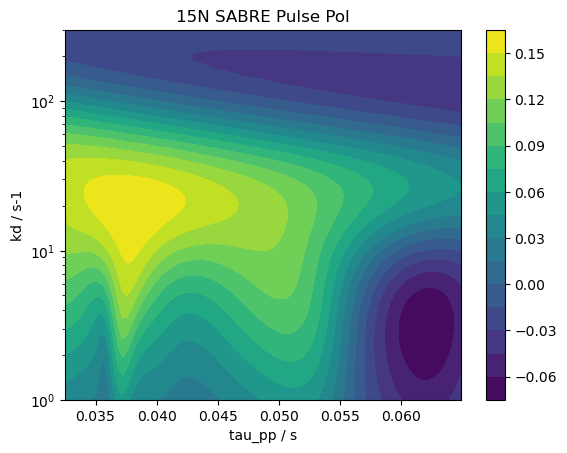

In [55]:
cs = plt.contourf(tau_ppsv, kdsv, P_2, levels=20)
cbar = plt.colorbar(cs) 
plt.plot()
plt.xlabel('tau_pp / s')
plt.ylabel('kd / s-1')
plt.yscale('log')
plt.title('15N SABRE Pulse Pol')
plt.show()

Or we cah plot in phs

In [71]:
tau_pps[P_2[:, arg_nearest(kds, 40)].argmax()] 

0.034291551145483726